In [ ]:
!pip install sympy -q

In [ ]:
import os
import re
import pickle
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict, defaultdict
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# SymPy for physics validation
import sympy as sp


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs('./checkpoints', exist_ok=True)
DATA_DIR = "./data/processed"
os.makedirs(DATA_DIR, exist_ok=True)

Using device: cuda


In [ ]:
# Cell 2: Amplitude Tokenizer with Mandelstam Encoding
# This class handles tokenization of amplitude and squared amplitude expressions
# It implements Mandelstam tagging (replacing s_12 with <S>, etc.) and token type classification

class AmplitudeTokenizer:
    def __init__(self, index_pool_size=100, special_symbols=None, to_replace=True):
        """
        Initialize tokenizer with index pool for normalization.
        index_pool_size: number of generic index placeholders
        to_replace: whether to normalize indices (should be True for training)
        """
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace

        if special_symbols is None:
            self.special_symbols = [
                '<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>',
                '<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'
            ]
        else:
            self.special_symbols = special_symbols

        # Index pools for normalization
        self.index_pool = [f"INDEX_{i}" for i in range(index_pool_size)]
        self.particle_index_pool = [f"PINDEX_{i}" for i in range(index_pool_size)]

        # Regex patterns for index detection
        self.pattern_particle = re.compile(r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)')
        self.pattern_num_123 = re.compile(r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b')
        self.pattern_momentum = re.compile(r'[ps]_(\d+)')

    @staticmethod
    def remove_whitespace(text):
        """Remove all whitespace from text"""
        return re.sub(r'\s+', '', text)

    @staticmethod
    def split_expression(text):
        """Split expression by spaces into tokens"""
        return re.split(r' ', text)

    def normalize_indices(self, text):
        """
        Replace arbitrary numeric indices with generic placeholders.
        This prevents the model from memorizing arbitrary IDs.
        Mandelstam variables (s_12, etc.) are protected from replacement.
        """
        if not self.to_replace:
            return text

        text = self.remove_whitespace(text)

        # Protect Mandelstam variables with multiple digits
        text = re.sub(r'\bs_(\d{2,})\b', lambda m: f'__MAND_{m.group(1)}__', text)

        # Replace momentum variables
        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r'\bs_(\d+)\b', r'MOMENTUM_\1', text)

        # Restore Mandelstam variables
        text = re.sub(r'__MAND_(\d+)__', r's_\1', text)

        # Handle LaTeX formatting
        text = text.replace('\\\\', '\\').replace('\\', r' \\ ').replace('%', ' % ')

        # Find and replace generic indices
        index_matches = list(OrderedDict.fromkeys(
            self.pattern_num_123.findall(text)
        ))

        index_iter = iter(self.index_pool)
        index_mapping = {}
        for match in index_matches:
            try:
                index_mapping[match] = next(index_iter)
            except StopIteration:
                raise RuntimeError(f"Index pool exhausted. Increase index_pool_size (currently {self.index_pool_size})")

        for old, new in sorted(index_mapping.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        # Find and replace particle indices (i, j, k, l)
        particle_matches = list(OrderedDict.fromkeys(
            m.group('target')
            for m in sorted(self.pattern_particle.finditer(text), key=lambda m: m.start())
        ))

        particle_iter = iter(self.particle_index_pool)
        particle_mapping = {}
        for match in particle_matches:
            try:
                particle_mapping[match] = next(particle_iter)
            except StopIteration:
                raise RuntimeError("Particle index pool exhausted. Increase index_pool_size")

        for old, new in sorted(particle_mapping.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        return text

    def tokenize_amplitude(self, amplitude_text):
        """
        Tokenize amplitude expression with Mandelstam encoding.
        Returns list of tokens.
        """
        if self.to_replace:
            text = self.normalize_indices(amplitude_text)
        else:
            text = amplitude_text

        text = self.remove_whitespace(text)

        # Handle special symbols
        text = text.replace('\\\\', '\\').replace('\\', r' \\ ').replace('%', ' % ')
        text = text.replace("(*)", " CONJ ")
        text = text.replace("(theta_W)", "_theta_W")

        # Isolate mathematical symbols
        for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
            text = text.replace(symbol, f' {symbol} ')

        # Handle index placeholders
        text = text.replace("_PINDEX", "_ PINDEX").replace("_INDEX", "_ INDEX")
        text = text.replace("reg_prop", " reg_prop ")

        # Clean up extra spaces
        text = re.sub(r' {2,}', ' ', text)

        # Split into tokens
        tokens = [t for t in self.split_expression(text) if t]

        # Apply Mandelstam tagging
        tokens = self.tag_mandelstam(tokens)
        return tokens

    def tokenize_squared(self, squared_text):
        """
        Tokenize squared amplitude expression with Mandelstam encoding.
        Returns list of tokens.
        """
        if self.to_replace:
            # Protect multi-digit Mandelstam variables
            protected = re.sub(r'\bs_(\d{2,})\b',
                              lambda m: f'__MAND_{m.group(1)}__',
                              squared_text)
            text = self.normalize_indices(protected)
            text = re.sub(r'__MAND_(\d+)__', r's_\1', text)
        else:
            text = squared_text

        text = self.remove_whitespace(text)
        text = text.replace("(theta_W)", "_theta_W")

        # Isolate mathematical symbols
        for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
            text = text.replace(symbol, f' {symbol} ')

        # Handle mass terms
        text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)

        # Handle Mandelstam variables
        text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)

        text = text.replace("reg_prop", " reg_prop ")
        text = re.sub(r' {2,}', ' ', text)

        tokens = [t for t in self.split_expression(text) if t]
        tokens = self.tag_mandelstam(tokens)
        return tokens

    def tag_mandelstam(self, tokens):
        """
        Replace Mandelstam variables with semantic tokens:
        s_12 → <S>, s_34 → <S_CROSS>
        s_13 → <T>, s_24 → <T_CROSS>
        s_14 → <U>, s_23 → <U_CROSS>

        This encodes crossing symmetry relationships directly into tokens.
        """
        mandelstam_map = {
            's_12': '<S>',       's_21': '<S>',
            's_13': '<T>',       's_31': '<T>',
            's_14': '<U>',       's_41': '<U>',
            's_23': '<U_CROSS>', 's_32': '<U_CROSS>',
            's_24': '<T_CROSS>', 's_42': '<T_CROSS>',
            's_34': '<S_CROSS>', 's_43': '<S_CROSS>',
        }
        return [mandelstam_map.get(tok, tok) for tok in tokens]

    def get_token_types(self, tokens):
        """
        Assign physics type labels to each token.
        This enables physics-informed embeddings.

        Type 0: MOMENTUM (Mandelstam variables, MOMENTUM_*)
        Type 1: MASS (m_e, m_u, reg_prop)
        Type 2: OPERATOR (gamma, sigma, color factors)
        Type 3: INDEX (INDEX_*, PINDEX_*)
        Type 4: ALGEBRAIC (+, -, *, /, ^, numbers)
        Type 5: SPECIAL (<PAD>, <BOS>, <EOS>, etc.)
        """
        MOMENTUM_TOKENS = {
            '<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'
        }
        SPECIAL_TOKENS = {
            '<PAD>', '<UNK>', '<BOS>', '<EOS>',
            '<SEP>', '<TERM0>', '<TERM1>'
        }

        type_labels = []
        for tok in tokens:
            if tok in MOMENTUM_TOKENS or tok.startswith('MOMENTUM_'):
                type_labels.append(0)  # MOMENTUM
            elif tok.startswith('m_') or tok == 'reg_prop':
                type_labels.append(1)  # MASS
            elif any(x in tok for x in ['gamma', 'sigma', 'eta', 'eps', 'del',
                                         'tau', 'mu', 'rho', 'gam', 'vho', 'CONJ',
                                         'T_C', 'G_{']):
                type_labels.append(2)  # OPERATOR
            elif tok.startswith('INDEX_') or tok.startswith('PINDEX_'):
                type_labels.append(3)  # INDEX
            elif tok in SPECIAL_TOKENS:
                type_labels.append(5)  # SPECIAL
            else:
                type_labels.append(4)  # ALGEBRAIC
        return type_labels

    def tokenize_with_types(self, amplitude_text):
        """
        Tokenize amplitude and return both tokens and their type labels.
        """
        tokens = self.tokenize_amplitude(amplitude_text)
        types = self.get_token_types(tokens)
        return tokens, types

Vocabulary

In [ ]:
# Cell 3: Vocabulary Class for Token-to-Index Mapping

class Vocabulary:
    """
    Maps tokens to integer indices and vice versa.
    Special tokens are placed at fixed positions for consistent indexing.
    """
    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=[5,6]):

        tokens = list(tokens)
        # Remove special tokens from regular tokens
        for special in special_symbols:
            if special in tokens:
                tokens.remove(special)

        self.token_list = special_symbols + tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.token_list)}
        self.idx_to_token = {idx: token for token, idx in self.token_to_idx.items()}

        self.pad_idx = pad_idx
        self.unk_idx = unk_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.sep_idx = sep_idx
        self.term_idx = term_idx

        self.pad_tok = special_symbols[pad_idx]
        self.unk_tok = special_symbols[unk_idx]
        self.bos_tok = special_symbols[bos_idx]
        self.eos_tok = special_symbols[eos_idx]
        self.sep_tok = special_symbols[sep_idx]

        self.special_indices = set(self.token_to_idx[sym] for sym in special_symbols)

    def encode(self, tokens):
        """Convert token list to integer indices."""
        return [self.token_to_idx.get(token, self.unk_idx) for token in tokens]

    def decode(self, indices, include_special=True):
        """Convert integer indices back to tokens."""
        if include_special:
            return [self.idx_to_token.get(idx, self.unk_tok) for idx in indices]
        else:
            return [
                self.idx_to_token.get(idx, self.unk_tok)
                for idx in indices
                if idx not in self.special_indices or idx == self.sep_idx
            ]

    def __len__(self):
        return len(self.token_list)

    def __getitem__(self, item):
        if isinstance(item, int):
            return self.idx_to_token.get(item, self.unk_tok)
        return self.token_to_idx.get(item, self.unk_idx)

    def tokens(self):
        return self.token_list

Loading the Preprocessed data

In [ ]:
# This file contains tokenized QED and QCD data with Mandelstam encoding already applied

DATA_PATH = '/content/data/processed/processed_data2.pkl'

with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)


qed_train = data['qed']['train']
qed_val = data['qed']['val']
qed_test = data['qed']['test']


qed_src_vocab = data['qed']['src_vocab']  # Source vocabulary (amplitude tokens)
qed_tgt_vocab = data['qed']['tgt_vocab']  # Target vocabulary (squared amplitude tokens)

print(f"QED Train: {len(qed_train)} samples")
print(f"QED Val: {len(qed_val)} samples")
print(f"QED Test: {len(qed_test)} samples")
print(f"QED Source vocabulary size: {len(qed_src_vocab)}")
print(f"QED Target vocabulary size: {len(qed_tgt_vocab)}")

QED Train: 288 samples
QED Val: 36 samples
QED Test: 36 samples
QED Source vocabulary size: 125
QED Target vocabulary size: 43


Unified Vocab

In [ ]:
# Since we use an encoder-decoder architecture, we need a single vocabulary
# that combines source (amplitude) and target (squared amplitude) tokens

class UnifiedVocabulary:
    def __init__(self, src_vocab, tgt_vocab):
        special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>',
                          '<TERM0>', '<TERM1>', '<S>', '<T>', '<U>',
                          '<S_CROSS>', '<T_CROSS>', '<U_CROSS>']

        all_tokens = []
        seen = set()

        # Add special tokens first
        for tok in special_tokens:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        # Add source vocabulary tokens
        for tok in src_vocab.token_list:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        # Add target vocabulary tokens
        for tok in tgt_vocab.token_list:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        self.token_list = all_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(all_tokens)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}

        self.pad_idx = self.token_to_idx.get('<PAD>', 0)
        self.bos_idx = self.token_to_idx.get('<BOS>', 2)
        self.eos_idx = self.token_to_idx.get('<EOS>', 3)
        self.unk_idx = self.token_to_idx.get('<UNK>', 1)
        self.sep_idx = self.token_to_idx.get('<SEP>', 4)

        print(f"Unified vocabulary size: {len(self.token_list)}")
        print(f"  Source had: {len(src_vocab)}")
        print(f"  Target had: {len(tgt_vocab)}")
        print(f"  Special tokens: {len(special_tokens)}")

    def encode(self, tokens):
        return [self.token_to_idx.get(t, self.unk_idx) for t in tokens]

    def decode(self, indices, include_special=False):
        tokens = [self.idx_to_token.get(i, '<UNK>') for i in indices]
        if not include_special:
            specials = {'<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>',
                       '<TERM0>', '<TERM1>', '<S>', '<T>', '<U>',
                       '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'}
            tokens = [t for t in tokens if t not in specials]
        return tokens

    def __len__(self):
        return len(self.token_list)


unified_vocab = UnifiedVocabulary(qed_src_vocab, qed_tgt_vocab)
print(f"\nUsing unified vocabulary with {len(unified_vocab)} tokens")

Unified vocabulary size: 135
  Source had: 125
  Target had: 43
  Special tokens: 13

Using unified vocabulary with 135 tokens


Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Create positional encodings using sine and cosine functions
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                            -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # Add batch dimension
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Add positional encoding to input embeddings
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

Physics informed Encoder

In [ ]:
# This is the encoder with token type embeddings for physics-aware representation

class PhysicsInformedTextEncoder(nn.Module):
    def __init__(self, vocab_size: int, num_types: int = 6, d_model: int = 256,
                 nhead: int = 8, num_layers: int = 4, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model

        # Token embeddings (maps tokens to vectors)
        self.token_embed = nn.Embedding(vocab_size, d_model)

        # Physics token type embeddings (separate embedding for each of 6 physics types)
        self.type_embed = nn.Embedding(num_types, d_model)

        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)

        # Standard transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, token_ids: torch.Tensor, type_ids: torch.Tensor,
                src_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Forward pass through encoder.
        Combines token embeddings and type embeddings with positional encoding.
        """
        # Sum token and type embeddings
        x = self.token_embed(token_ids) + self.type_embed(type_ids)
        x = x * math.sqrt(self.d_model)
        x = self.pos_encoding(x)

        # Create padding mask for attention
        if src_mask is not None:
            key_padding_mask = src_mask
        else:
            key_padding_mask = (token_ids == 0)

        # Apply transformer encoder
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)
        return self.layer_norm(x)

Physics informed model

In [ ]:
# Full encoder-decoder transformer with physics-informed components

class PhysicsInformedModel(nn.Module):
    def __init__(self, vocab_size: int, num_types: int = 6, d_model: int = 256,
                 nhead: int = 8, num_layers: int = 6, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size

        # Encoder with token type embeddings
        self.text_encoder = PhysicsInformedTextEncoder(
            vocab_size, num_types, d_model, nhead, num_layers, dropout
        )

        # Decoder layers
        decoder_layer = nn.TransformerDecoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers)

        # Output projection
        self.output_proj = nn.Linear(d_model, vocab_size)

        # Target embeddings
        self.tgt_embed = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)

        # Tie output projection weights with input embeddings
        self.output_proj.weight = self.text_encoder.token_embed.weight

        self._init_weights()

    def _init_weights(self):
        """Initialize weights using Xavier uniform for better convergence."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src_ids: torch.Tensor, src_types: torch.Tensor,
                tgt_ids: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through encoder-decoder.
        src_ids: source token indices (amplitude)
        src_types: source token types (physics categories)
        tgt_ids: target token indices (squared amplitude)
        """
        # Create padding mask
        src_mask = (src_ids == 0)

        # Encode source sequence
        memory = self.text_encoder(src_ids, src_types, src_mask)

        # Prepare decoder input
        tgt_input = tgt_ids
        tgt_emb = self.tgt_embed(tgt_input) * math.sqrt(self.d_model)
        tgt_emb = self.pos_encoding(tgt_emb)

        # Create causal mask to prevent looking ahead
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_input.size(1)).to(device)

        # Decode
        output = self.decoder(tgt_emb, memory, tgt_mask=tgt_mask)

        # Project to vocabulary
        logits = self.output_proj(output)

        return logits

Physics informed Dataset

In [ ]:
# Applies physics-informed masking during training to help model learn physical units

class PhysicsInformedDataset(Dataset):
    def __init__(self, data_list: List[Dict], vocab, max_len: int = 512, use_physics_masking: bool = True):
        self.data = data_list
        self.vocab = vocab
        self.max_len = max_len
        self.pad_idx = vocab.pad_idx
        self.bos_idx = vocab.bos_idx
        self.eos_idx = vocab.eos_idx
        self.use_physics_masking = use_physics_masking

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict:
        item = self.data[idx]

        amp_tokens = item['amp_tokens']
        amp_types = item['amp_types']
        sq_tokens = item['sq_tokens']

        src_ids = self.vocab.encode(amp_tokens)
        src_type_ids = amp_types

        # Add BOS and EOS tokens
        src_ids = [self.bos_idx] + src_ids + [self.eos_idx]
        src_type_ids = [5] + src_type_ids + [5]  # Type 5 = SPECIAL

        # Apply physics-informed masking during training (15% of samples)
        if self.use_physics_masking and random.random() < 0.15:
            src_ids, src_type_ids = self._physics_masking(src_ids, src_type_ids)

        tgt_ids = self.vocab.encode(sq_tokens)
        tgt_ids = [self.bos_idx] + tgt_ids + [self.eos_idx]

        # Truncate to max length
        src_ids = src_ids[:self.max_len]
        src_type_ids = src_type_ids[:self.max_len]
        tgt_ids = tgt_ids[:self.max_len]

        return {
            'src_ids': torch.tensor(src_ids, dtype=torch.long),
            'src_types': torch.tensor(src_type_ids, dtype=torch.long),
            'tgt_ids': torch.tensor(tgt_ids, dtype=torch.long)
        }

    def _physics_masking(self, src_ids, src_type_ids):
        """
        Physics-informed masking: masks entire physical units together.

        This forces the model to learn that:
        1. Mandelstam triples (<S>, <T>, <U>) appear together
        2. Coupling constants with exponents (e^2, e^4) are single units
        """
        masked_ids = src_ids.copy()

        # 1. Mask Mandelstam triples together
        mandelstam_tokens = {'<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'}
        mandelstam_positions = []

        for i, idx in enumerate(src_ids):
            token = self.vocab.idx_to_token.get(idx, '')
            if token in mandelstam_tokens:
                mandelstam_positions.append(i)

        # If we have at least three Mandelstam tokens, mask them together (80% probability)
        if len(mandelstam_positions) >= 3:
            for pos in mandelstam_positions[:3]:
                if random.random() < 0.8:
                    masked_ids[pos] = self.vocab.pad_idx

        # 2. Mask coupling constants with exponents (e^2, e^4)
        i = 0
        while i < len(src_ids) - 2:
            token_i = self.vocab.idx_to_token.get(src_ids[i], '')
            token_j = self.vocab.idx_to_token.get(src_ids[i+1], '')
            token_k = self.vocab.idx_to_token.get(src_ids[i+2], '')

            # Look for pattern: e ^ digit
            if token_i == 'e' and token_j == '^' and token_k.isdigit():
                # With 50% probability, mask the entire coupling unit
                if random.random() < 0.5:
                    masked_ids[i] = self.vocab.pad_idx      # mask 'e'
                    masked_ids[i+1] = self.vocab.pad_idx    # mask '^'
                    masked_ids[i+2] = self.vocab.pad_idx    # mask exponent
                i += 3
            else:
                i += 1

        return masked_ids, src_type_ids


def collate_fn(batch: List[Dict]) -> Dict:
    """Custom collate function for padding sequences in a batch."""
    src_ids = [item['src_ids'] for item in batch]
    src_types = [item['src_types'] for item in batch]
    tgt_ids = [item['tgt_ids'] for item in batch]

    src_ids_padded = pad_sequence(src_ids, batch_first=True, padding_value=0)
    src_types_padded = pad_sequence(src_types, batch_first=True, padding_value=0)
    tgt_ids_padded = pad_sequence(tgt_ids, batch_first=True, padding_value=0)

    return {
        'src_ids': src_ids_padded,
        'src_types': src_types_padded,
        'tgt_ids': tgt_ids_padded
    }

Physics Losses

In [ ]:

# Implements three physics-based auxiliary losses for QED

class PhysicsLossCalculator:
    def __init__(self, vocab):
        self.vocab = vocab

    def compute_physics_loss(self, logits):
        """
        Compute physics-based auxiliary losses from predicted token indices.

        Three physics constraints:
        1. Coupling Parity: e appears only in even powers (e^2, e^4)
        2. Crossing Symmetry: <S> with <S_CROSS>, <T> with <T_CROSS>, <U> with <U_CROSS>
        3. Propagator Structure: reg_prop appears 0 or 1 time

        Returns a tensor that can be backpropagated.
        """
        pred_indices = logits.argmax(dim=-1)
        physics_loss = 0.0


        # Loss 1: Coupling Parity - e appears only in even powers
        # Physics: |M|² ∝ e^(2n) for QED

        for batch in pred_indices:
            e_power = 0
            i = 0
            while i < len(batch) - 2:
                token_i = self.vocab.idx_to_token.get(batch[i].item(), '')
                token_j = self.vocab.idx_to_token.get(batch[i+1].item(), '')
                token_k = self.vocab.idx_to_token.get(batch[i+2].item(), '')
                if token_i == 'e' and token_j == '^' and token_k.isdigit():
                    e_power += int(token_k)
                    i += 3
                else:
                    i += 1
            # Penalize odd total exponent
            if e_power % 2 != 0:
                physics_loss += 0.3


        # Loss 2: Crossing Symmetry - Paired Mandelstam variables
        # Physics: <S> with <S_CROSS>, <T> with <T_CROSS>, <U> with <U_CROSS>

        for batch in pred_indices:
            tokens = [self.vocab.idx_to_token.get(idx.item(), '') for idx in batch]
            has_S = '<S>' in tokens
            has_S_cross = '<S_CROSS>' in tokens
            has_T = '<T>' in tokens
            has_T_cross = '<T_CROSS>' in tokens
            has_U = '<U>' in tokens
            has_U_cross = '<U_CROSS>' in tokens

            # Penalize if one appears without its crossed counterpart
            if has_S != has_S_cross:
                physics_loss += 0.2
            if has_T != has_T_cross:
                physics_loss += 0.2
            if has_U != has_U_cross:
                physics_loss += 0.2


        # Loss 3: Propagator Structure
        # Physics: reg_prop appears in valid patterns (0 or 1 time)

        for batch in pred_indices:
            tokens = [self.vocab.idx_to_token.get(idx.item(), '') for idx in batch]
            reg_prop_count = tokens.count('reg_prop')
            # Penalize if count is not 0 or 1
            if reg_prop_count not in [0, 1]:
                physics_loss += 0.2

        # Return as tensor for gradient computation
        return torch.tensor(physics_loss / len(pred_indices),
                           device=logits.device,
                           dtype=torch.float32,
                           requires_grad=True)

Sympy validation

In [ ]:
# It verifies that generated expressions satisfy crossing symmetry

def validate_with_sympy(predicted_tokens):
    """
    Convert predicted tokens to a SymPy expression and check crossing symmetry.

    Checks three crossing symmetries:
    1. s ↔ t (t-channel crossing)
    2. s ↔ u (u-channel crossing)
    3. t ↔ u (combined crossing)

    Returns:
        is_valid: Boolean indicating if all symmetries hold
        message: Description of any violations
        violations: List of which symmetries failed
    """
    if not predicted_tokens:
        return False, "Empty token sequence", []

    # Convert tokens to SymPy expression string
    expr_str = ""
    for token in predicted_tokens:
        if token == '<S>':
            expr_str += "s"
        elif token == '<T>':
            expr_str += "t"
        elif token == '<U>':
            expr_str += "u"
        elif token == '<S_CROSS>':
            expr_str += "s_cross"
        elif token == '<T_CROSS>':
            expr_str += "t_cross"
        elif token == '<U_CROSS>':
            expr_str += "u_cross"
        elif token.startswith('m_'):
            expr_str += token
        elif token == 'e':
            expr_str += "e"
        elif token == '^':
            expr_str += "**"
        elif token in ['+', '-', '*', '/', '(', ')']:
            expr_str += token
        elif token.isdigit():
            expr_str += token
        else:
            # Skip INDEX, PINDEX, gamma matrices
            continue

    try:
        # Define symbols
        s, t, u = sp.symbols('s t u')
        e = sp.symbols('e')

        # Parse expression
        expr = sp.sympify(expr_str)
        expr = sp.simplify(expr)

        violations = []

        # Check 1: s ↔ t crossing symmetry
        try:
            expr_st = expr.subs({s: t, t: s})
            expr_st = sp.simplify(expr_st)
            diff_st = sp.simplify(expr - expr_st)
            if diff_st != 0:
                violations.append("s↔t")
        except Exception as e:
            violations.append(f"s↔t (error)")

        # Check 2: s ↔ u crossing symmetry
        try:
            expr_su = expr.subs({s: u, u: s})
            expr_su = sp.simplify(expr_su)
            diff_su = sp.simplify(expr - expr_su)
            if diff_su != 0:
                violations.append("s↔u")
        except Exception as e:
            violations.append(f"s↔u (error)")

        # Check 3: t ↔ u crossing symmetry
        try:
            expr_tu = expr.subs({t: u, u: t})
            expr_tu = sp.simplify(expr_tu)
            diff_tu = sp.simplify(expr - expr_tu)
            if diff_tu != 0:
                violations.append("t↔u")
        except Exception as e:
            violations.append(f"t↔u (error)")

        if violations:
            return False, f"Crossing symmetry violations: {', '.join(violations)}", violations
        return True, "All crossing symmetries satisfied", []

    except Exception as e:
        return False, f"Parsing error: {str(e)[:100]}", []

Training and Validation functions

In [ ]:
def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer,
                    criterion: nn.Module, device: torch.device, physics_calc) -> Tuple[float, float]:
    """
    Train for one epoch with physics-informed auxiliary loss.

    Returns:
        tuple: (ce_loss, physics_loss) - average cross-entropy loss and physics loss
    """
    model.train()
    total_ce_loss = 0.0
    total_physics_loss = 0.0
    total_tokens = 0

    for batch in loader:
        src_ids = batch['src_ids'].to(device)
        src_types = batch['src_types'].to(device)
        tgt_ids = batch['tgt_ids'].to(device)

        logits = model(src_ids, src_types, tgt_ids)

        tgt_output = tgt_ids[:, 1:]
        logits = logits[:, :-1, :]

        # Standard cross-entropy loss
        ce_loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        # Physics-based auxiliary loss
        physics_loss = physics_calc.compute_physics_loss(logits)

        # Combined loss (weight physics loss by 0.1)
        loss = ce_loss + 0.05 * physics_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        num_tokens = (tgt_output != 0).sum().item()
        total_ce_loss += ce_loss.item()
        total_physics_loss += physics_loss.item()
        total_tokens += num_tokens

    return (total_ce_loss / max(total_tokens, 1),
            total_physics_loss / len(loader))




In [ ]:
@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader, criterion: nn.Module,
             device: torch.device) -> Tuple[float, float]:
    """
    Validate model performance with token accuracy.

    Returns:
        tuple: (loss, token_accuracy)
    """
    model.eval()
    total_loss = 0
    total_tokens = 0
    total_correct = 0

    for batch in loader:
        src_ids = batch['src_ids'].to(device)
        src_types = batch['src_types'].to(device)
        tgt_ids = batch['tgt_ids'].to(device)

        logits = model(src_ids, src_types, tgt_ids)

        tgt_output = tgt_ids[:, 1:]
        logits = logits[:, :-1, :]

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        preds = logits.argmax(dim=-1)

        mask = (tgt_output != 0)
        correct = (preds == tgt_output) & mask
        total_correct += correct.sum().item()

        num_tokens = mask.sum().item()
        total_loss += loss.item()
        total_tokens += num_tokens

    return (total_loss / max(total_tokens, 1),
            total_correct / max(total_tokens, 1))


Hyperparameters

In [ ]:
# Model architecture
VOCAB_SIZE = len(unified_vocab)
NUM_TYPES = 6
D_MODEL = 256
NHEAD = 8
NUM_LAYERS = 6  # Decoder layers (Encoder has 4 layers internally)
DROPOUT = 0.1
MAX_LEN = 512

# Training
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
PATIENCE = 10

Initializing Datasets and the Model

In [ ]:
# Creating datasets with physics-informed masking enabled for training only
train_dataset = PhysicsInformedDataset(qed_train, unified_vocab, max_len=MAX_LEN, use_physics_masking=True)
val_dataset = PhysicsInformedDataset(qed_val, unified_vocab, max_len=MAX_LEN, use_physics_masking=False)
test_dataset = PhysicsInformedDataset(qed_test, unified_vocab, max_len=MAX_LEN, use_physics_masking=False)

# Creating the dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Initializing the  model
model = PhysicsInformedModel(
    vocab_size=VOCAB_SIZE,
    num_types=NUM_TYPES,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT)

# the total parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# Physics loss calculator
physics_calc = PhysicsLossCalculator(unified_vocab)


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')


model = model.to(device)
print(f"Model moved to: {next(model.parameters()).device}")

# Early stopping variables
best_val_loss = float('inf')
patience_counter = 0
best_state = None

Train batches: 9
Val batches: 2
Test batches: 2

Total trainable parameters: 11,130,503
Model moved to: cuda:0


Model Training

In [ ]:
train_losses = []
val_losses = []
val_accuracies = []
train_physics_losses = []


for epoch in range(1, EPOCHS + 1):
    train_loss, train_physics_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device, physics_calc
    )
    scheduler.step()

    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    train_physics_losses.append(train_physics_loss)


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, './checkpoints/qed_best.pt')
        improved = "★"
    else:
        patience_counter += 1
        improved = ""


    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
              f"Physics Loss: {train_physics_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {improved}")


    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Load best model
if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"\n✓ Loaded best model (val_loss: {best_val_loss:.4f})")

Epoch   1/50 | Train Loss: 3.7604 | Physics Loss: 0.0076 | Val Loss: 2.9696 | Val Acc: 0.2016 ★
Epoch   5/50 | Train Loss: 1.1803 | Physics Loss: 0.3549 | Val Loss: 0.9971 | Val Acc: 0.6877 ★
Epoch  10/50 | Train Loss: 0.5610 | Physics Loss: 0.4368 | Val Loss: 0.4601 | Val Acc: 0.8653 ★
Epoch  15/50 | Train Loss: 0.3084 | Physics Loss: 0.3778 | Val Loss: 0.2998 | Val Acc: 0.9074 ★
Epoch  20/50 | Train Loss: 0.2163 | Physics Loss: 0.2972 | Val Loss: 0.2387 | Val Acc: 0.9120 ★
Epoch  25/50 | Train Loss: 0.1626 | Physics Loss: 0.3215 | Val Loss: 0.2447 | Val Acc: 0.9077 
Epoch  30/50 | Train Loss: 0.1329 | Physics Loss: 0.3132 | Val Loss: 0.2275 | Val Acc: 0.9187 ★
Epoch  35/50 | Train Loss: 0.1081 | Physics Loss: 0.2819 | Val Loss: 0.2331 | Val Acc: 0.9178 
Epoch  40/50 | Train Loss: 0.0994 | Physics Loss: 0.2840 | Val Loss: 0.2214 | Val Acc: 0.9200 
Epoch  45/50 | Train Loss: 0.0919 | Physics Loss: 0.2972 | Val Loss: 0.2244 | Val Acc: 0.9255 
Epoch  50/50 | Train Loss: 0.0891 | Physics 

Plotting the Training Curves

(0.0, 1.0)

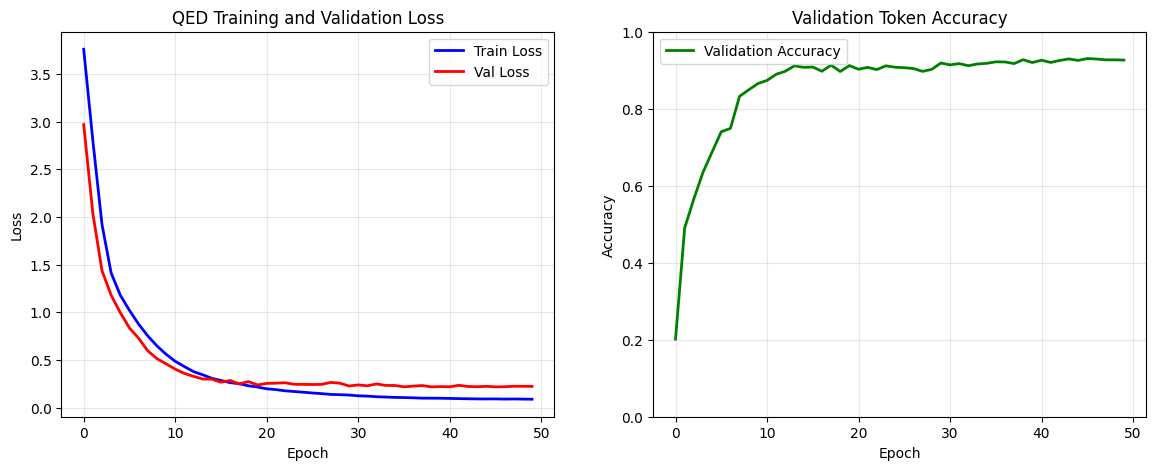

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('QED Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(val_accuracies, label='Validation Accuracy', color='green', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Token Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)


Test Evaluation

In [ ]:
# Evaluate on test set
test_loss, test_acc = validate(model, test_loader, criterion, device)


print("TEST SET RESULTS (QED)")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Token Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Save results
results = {
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'best_val_loss': best_val_loss,
    'final_val_accuracy': val_accuracies[-1] if val_accuracies else 0,
    'epochs_trained': len(train_losses)
}

print("\n Training Summary:")
print(f"  Best Validation Loss: {best_val_loss:.4f}")
print(f"  Final Validation Accuracy: {val_accuracies[-1]*100:.2f}%" if val_accuracies else "  N/A")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Total Epochs Trained: {len(train_losses)}")

TEST SET RESULTS (QED)
Test Loss: 0.1980
Test Token Accuracy: 0.9300 (93.00%)

 Training Summary:
  Best Validation Loss: 0.2186
  Final Validation Accuracy: 92.64%
  Test Accuracy: 93.00%
  Total Epochs Trained: 50


In [ ]:
# Saving only the encoder weights (not the whole model)
torch.save(model.text_encoder.state_dict(), './checkpoints/qed_encoder_pretrained.pt')
print("✓ Pre-trained encoder weights saved to ./checkpoints/qed_encoder_pretrained.pt")
print(f"  Encoder has {len(model.text_encoder.encoder.layers)} layers")

✓ Pre-trained encoder weights saved to ./checkpoints/qed_encoder_pretrained.pt
  Encoder has 6 layers
